In [7]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import utils
from sklearn.impute import SimpleImputer

from dataset import load_uci_dataset, encode_labels, get_holdout_dataloaders
from models import MLP
from losses import PolyLoss, CombinedCLoss
from engine import train_model, evaluate_model
from plot_utils import plot_training_history
from gdv_utils import calculate_gdv

print("=== 1. SETUP AMBIENTE E DOWNLOAD DATI ===")

config_init = utils.carica_configurazione("config.yaml")
dataset_id = config_init['dataset']['uci_id']
device = torch.device(config_init['training']['device'] if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

# Calcolo GDV Iniziale (Baseline geometrica su dati grezzi scalati)
X_raw, y_raw = load_uci_dataset(dataset_id)
y_encoded, n_classes = encode_labels(y_raw)
in_dim = X_raw.shape[1]

# Workaorund per poter calcolare il GDV anche con dati che presentano valori mancanti (NaN)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_raw)

print("Calcolo GDV geometrico iniziale in corso...")
X_scaled_baseline = StandardScaler().fit_transform(X_imputed)

X_tensor = torch.tensor(X_scaled_baseline, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

GDV_INIZIALE = calculate_gdv(X_tensor, y_tensor)

print(f"\n--- Dimensioni Rilevate dal Dataset (UCI {dataset_id}) ---")
print(f"Features (Input): {in_dim}")
print(f"Classi (Output):  {n_classes}")
print(f"GDV Dati Grezzi:  {GDV_INIZIALE:.4f}")
print("===================================================")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
=== 1. SETUP AMBIENTE E DOWNLOAD DATI ===
[*] Configurazione caricata da: config.yaml
Dispositivo in uso: cuda
Scaricamento del dataset UCI ID 365...
Calcolo GDV geometrico iniziale in corso...

--- Dimensioni Rilevate dal Dataset (UCI 365) ---
Features (Input): 65
Classi (Output):  2
GDV Dati Grezzi:  -0.0015


In [8]:
print("=== 2. RICARICAMENTO CONFIGURAZIONE E DATALOADER ===")

config = utils.carica_configurazione("config.yaml")

# Imposta il seed per la riproducibilità degli split
random_state = config['dataset'].get('random_state', 42)
torch.manual_seed(random_state)

# --- CREAZIONE VELOCE DATALOADER ---
batch_size = config['dataset']['batch_size']
train_loader, val_loader, test_loader = get_holdout_dataloaders(
    X_raw, y_encoded, batch_size=batch_size, random_state=random_state
)

# --- SETUP ARCHITETTURA DINAMICA ---
config_layers = config['model'].get('hidden_layers', "auto")

if config_layers == "auto":
    # Calcola da solo i layer migliori in base a in_dim
    hidden_layers = utils.get_auto_hidden_layers(in_dim, n_classes)
    print(f"Architettura Auto-Selezionata: {in_dim} -> {hidden_layers} -> {n_classes}")
    # Sovrascrive la config in RAM per le celle di addestramento
    config['model']['hidden_layers'] = hidden_layers 
else:
    print(f"Architettura Forzata da YAML: {in_dim} -> {config_layers} -> {n_classes}")

    
print(f"Dataloader creati! (Batch size: {batch_size})")
print("Pronto per l'addestramento.")

=== 2. RICARICAMENTO CONFIGURAZIONE E DATALOADER ===
[*] Configurazione caricata da: config.yaml
Architettura Auto-Selezionata: 65 -> [260, 130] -> 2
Dataloader creati! (Batch size: 64)
Pronto per l'addestramento.



Avvio Addestramento: Cross-Entropy su Dataset UCI ID 365 (Hold-Out)
Epoca 01/500 | Train Loss: 0.2030 | Val Loss: 0.1918 | Val Acc: 95.16% | Val GDV: -0.0193
Epoca 05/500 | Train Loss: 0.1576 | Val Loss: 0.1837 | Val Acc: 95.29% | Val GDV: -0.0190
Epoca 10/500 | Train Loss: 0.1275 | Val Loss: 0.1659 | Val Acc: 95.78% | Val GDV: -0.0362
Epoca 15/500 | Train Loss: 0.1155 | Val Loss: 0.1627 | Val Acc: 95.98% | Val GDV: -0.0577
Epoca 20/500 | Train Loss: 0.1162 | Val Loss: 0.1564 | Val Acc: 96.21% | Val GDV: -0.0704
Epoca 25/500 | Train Loss: 0.0977 | Val Loss: 0.1457 | Val Acc: 96.34% | Val GDV: -0.0734
Epoca 30/500 | Train Loss: 0.0919 | Val Loss: 0.1409 | Val Acc: 96.50% | Val GDV: -0.0637
Epoca 35/500 | Train Loss: 0.0860 | Val Loss: 0.1436 | Val Acc: 96.34% | Val GDV: -0.0495
Epoca 40/500 | Train Loss: 0.0810 | Val Loss: 0.1809 | Val Acc: 96.20% | Val GDV: -0.0561
Epoca 45/500 | Train Loss: 0.0759 | Val Loss: 0.1503 | Val Acc: 96.18% | Val GDV: -0.0468
Epoca 50/500 | Train Loss: 0.07

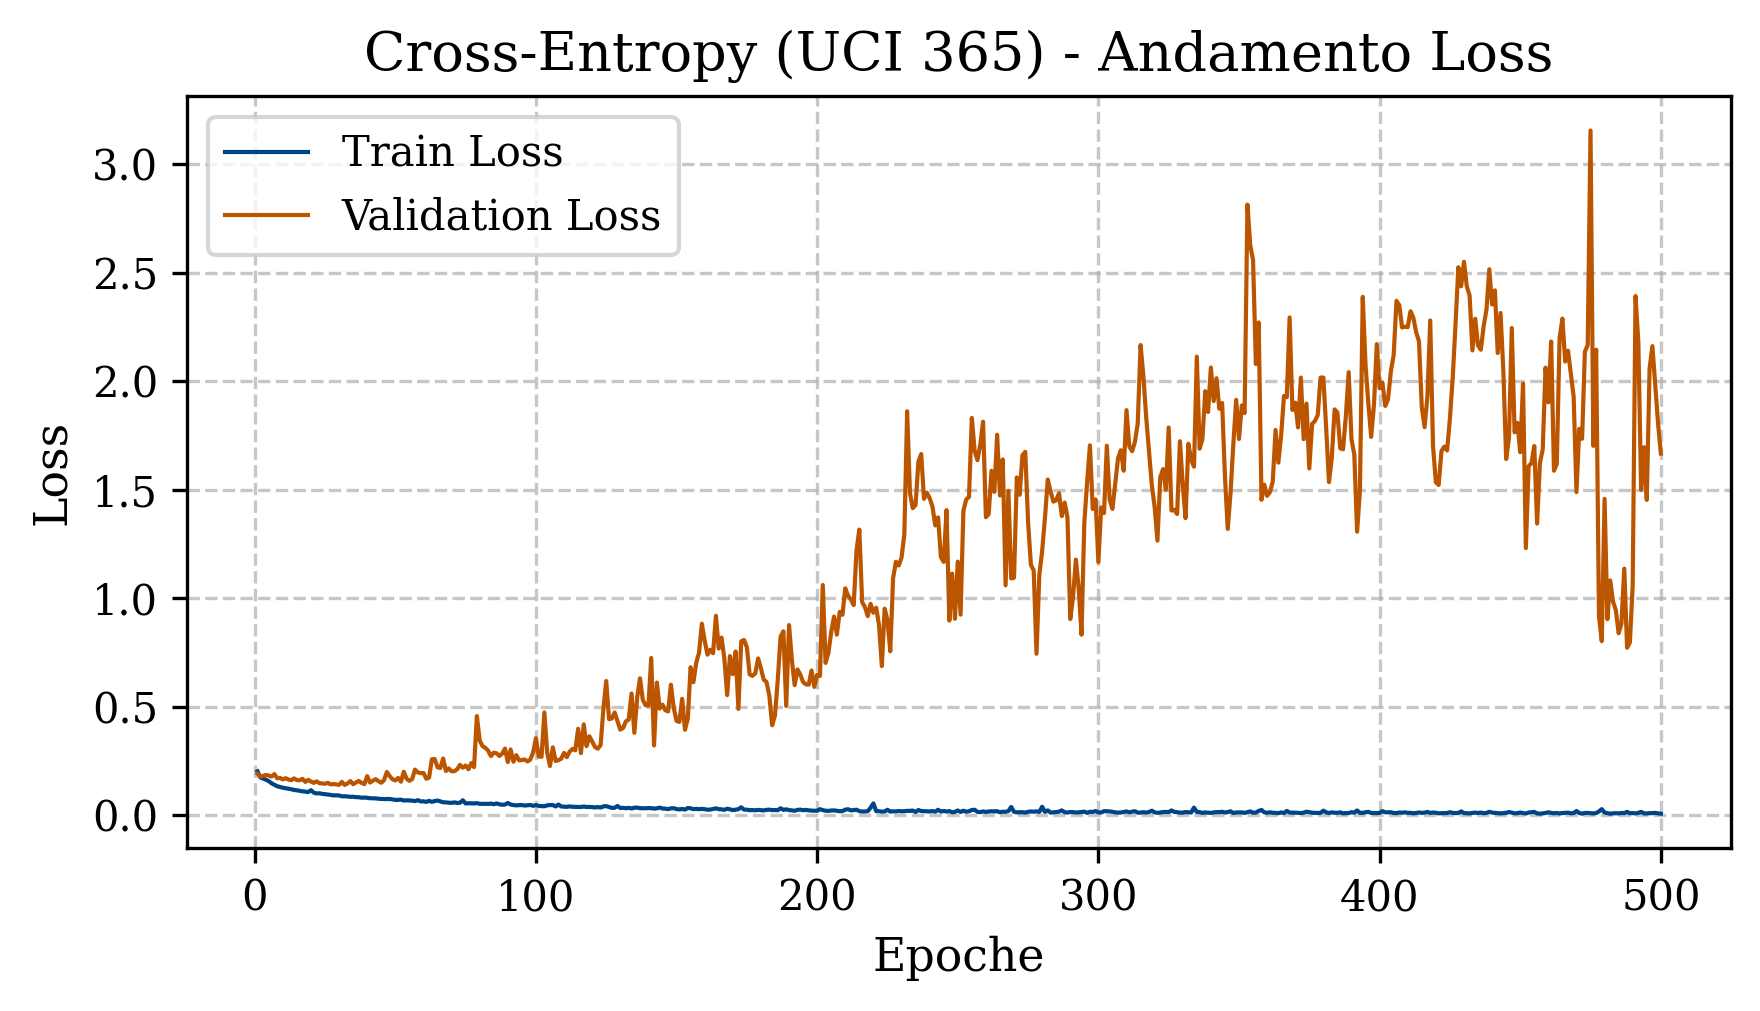

[*] Grafico salvato: results\{365}\plots\2026-05-11_16-37-26_Cross-Entropy_(UCI_365)_Accuracy.pdf


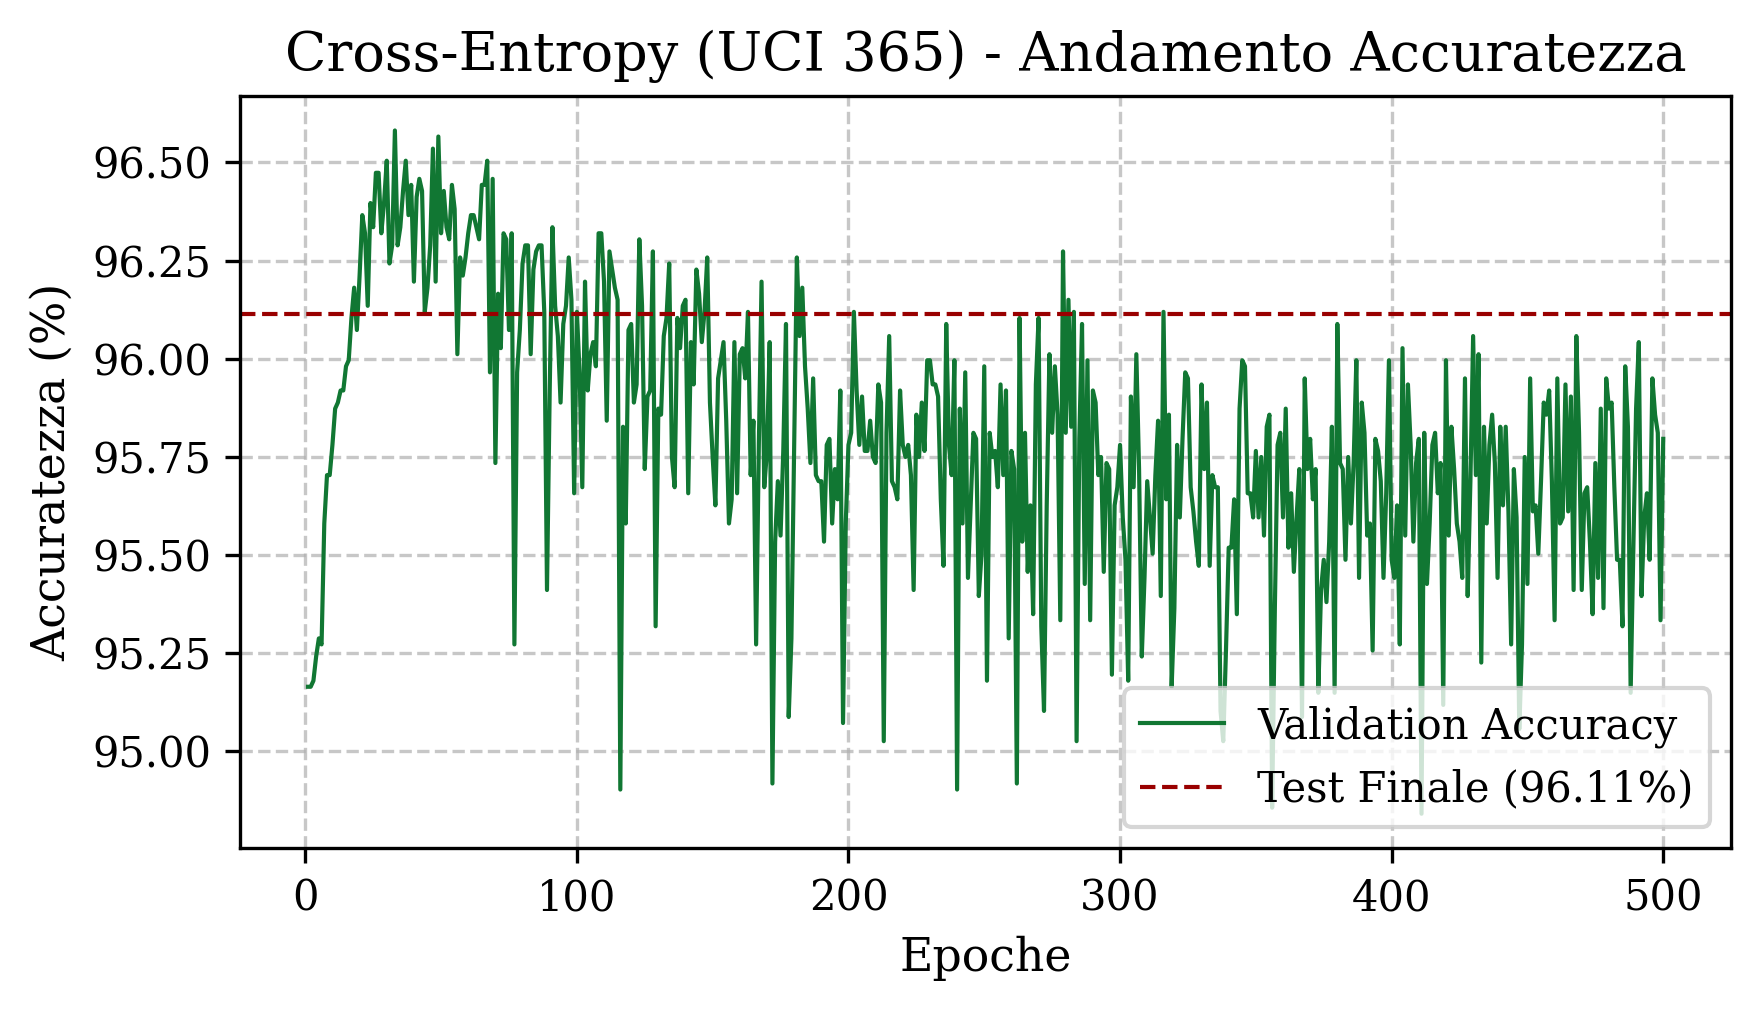

[*] Grafico salvato: results\{365}\plots\2026-05-11_16-37-26_Cross-Entropy_(UCI_365)_GDV.pdf


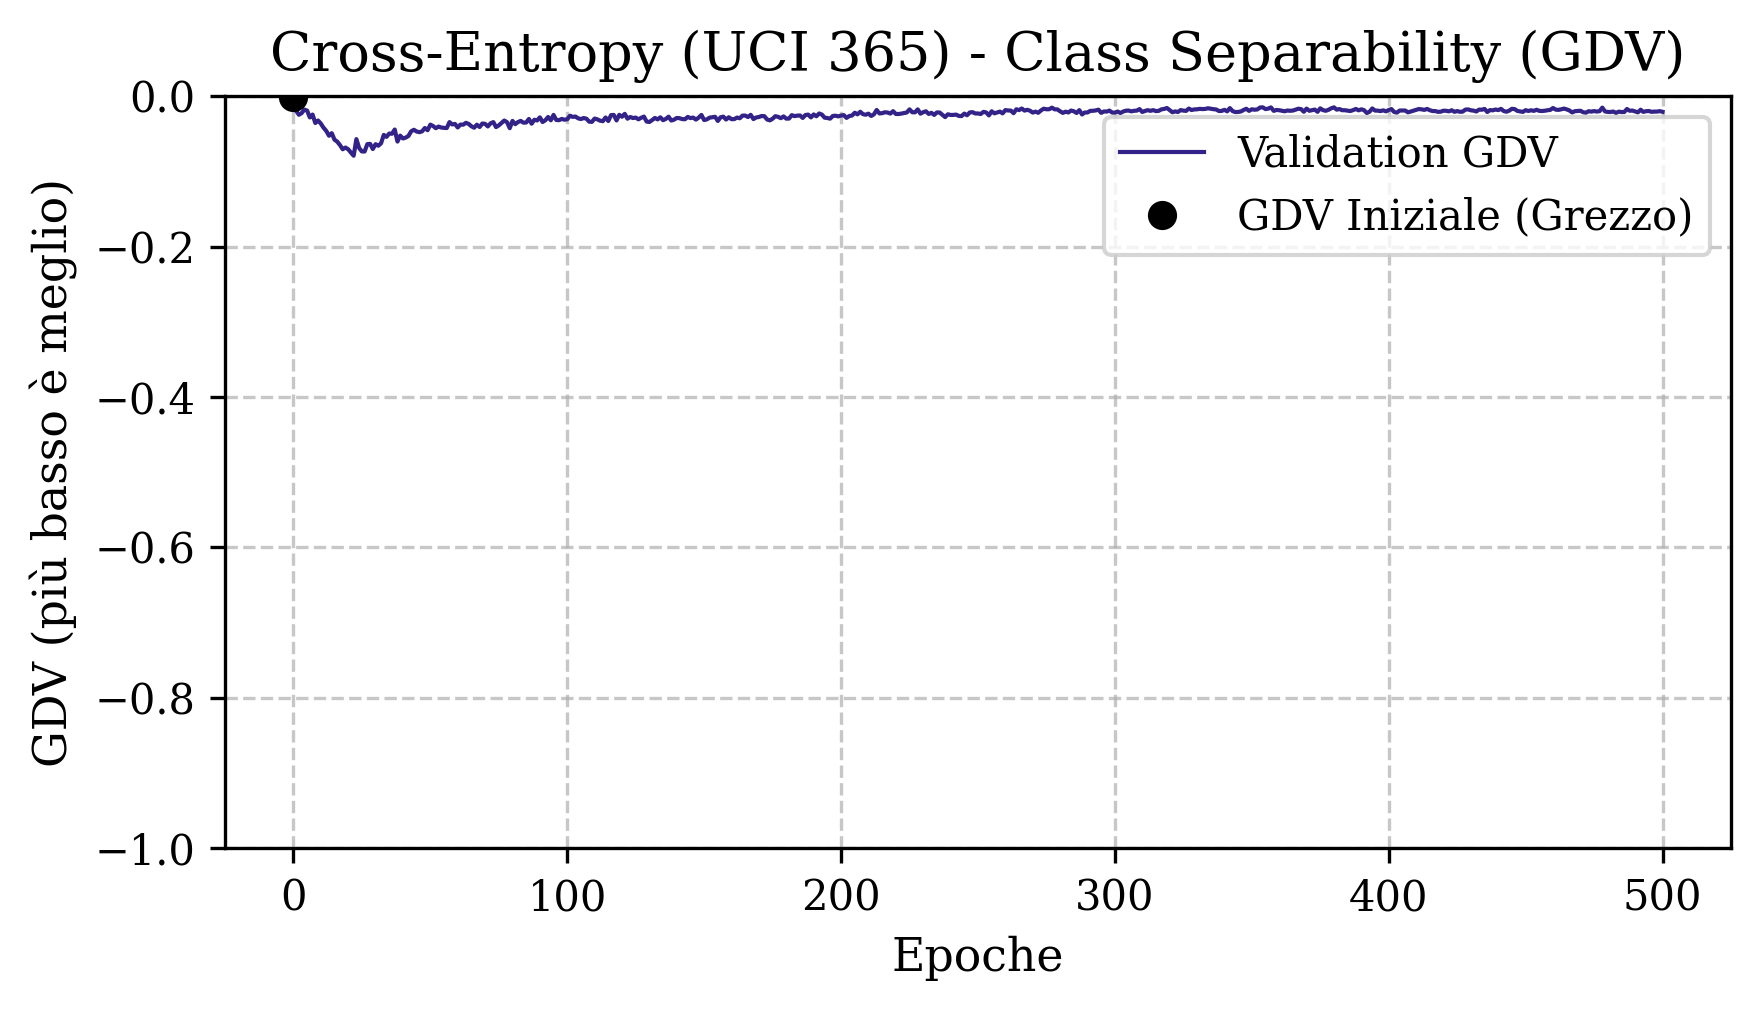

In [ ]:
# === ESPERIMENTO 1: BASELINE (CROSS-ENTROPY) ===
print(f"\nAvvio Addestramento: Cross-Entropy su Dataset UCI ID {dataset_id} (Hold-Out)")

torch.manual_seed(config['dataset'].get('random_state', 42))

model_ce = MLP(
    input_size=in_dim, 
    num_classes=n_classes,
    hidden_layers=config['model']['hidden_layers'],
    dropout_rate=config['model']['dropout_rate']
).to(device)

criterion_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.Adam(model_ce.parameters(), lr=config['training']['learning_rate'])

gdv_layer = model_ce.get_layer_for_gdv(index=config['model']['gdv_layer_index'])

history_ce, best_epoch_ce = train_model(
    model=model_ce, criterion=criterion_ce, optimizer=optimizer_ce, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=config['training']['epochs'], layer_for_gdv=gdv_layer
)

test_acc_ce = evaluate_model(model_ce, test_loader, device)
history_ce['test_acc'] = test_acc_ce
print(f"Accuratezza Test Finale: {test_acc_ce:.2f}%")

# MLOps: Salvataggio log e Grafici
utils.salva_storico_json(     
    history=history_ce,     
    nome_esperimento=f"HoldOut_CE_UCI_{dataset_id}",
    dataset_id=dataset_id
)
plot_training_history(
    history_ce, 
    model_name=f"Cross-Entropy (UCI {dataset_id})", 
    gdv_iniziale=GDV_INIZIALE,
    dataset_id=dataset_id
)


Avvio Addestramento: PolyLoss su Dataset UCI ID 365 (Hold-Out)
Epoca 01/500 | Train Loss: 0.3784 | Val Loss: 0.3422 | Val Acc: 95.13% | Val GDV: -0.0168
Epoca 05/500 | Train Loss: 0.2986 | Val Loss: 0.3369 | Val Acc: 95.26% | Val GDV: -0.0183
Epoca 10/500 | Train Loss: 0.2419 | Val Loss: 0.3073 | Val Acc: 95.84% | Val GDV: -0.0459
Epoca 15/500 | Train Loss: 0.2199 | Val Loss: 0.2865 | Val Acc: 96.07% | Val GDV: -0.0714
Epoca 20/500 | Train Loss: 0.1956 | Val Loss: 0.2744 | Val Acc: 96.21% | Val GDV: -0.0819
Epoca 25/500 | Train Loss: 0.1970 | Val Loss: 0.2727 | Val Acc: 96.54% | Val GDV: -0.0932
Epoca 30/500 | Train Loss: 0.1720 | Val Loss: 0.2686 | Val Acc: 96.38% | Val GDV: -0.0800
Epoca 35/500 | Train Loss: 0.1655 | Val Loss: 0.2670 | Val Acc: 96.32% | Val GDV: -0.0654
Epoca 40/500 | Train Loss: 0.1556 | Val Loss: 0.2755 | Val Acc: 96.30% | Val GDV: -0.0689
Epoca 45/500 | Train Loss: 0.1506 | Val Loss: 0.2739 | Val Acc: 96.54% | Val GDV: -0.0599
Epoca 50/500 | Train Loss: 0.1422 | 

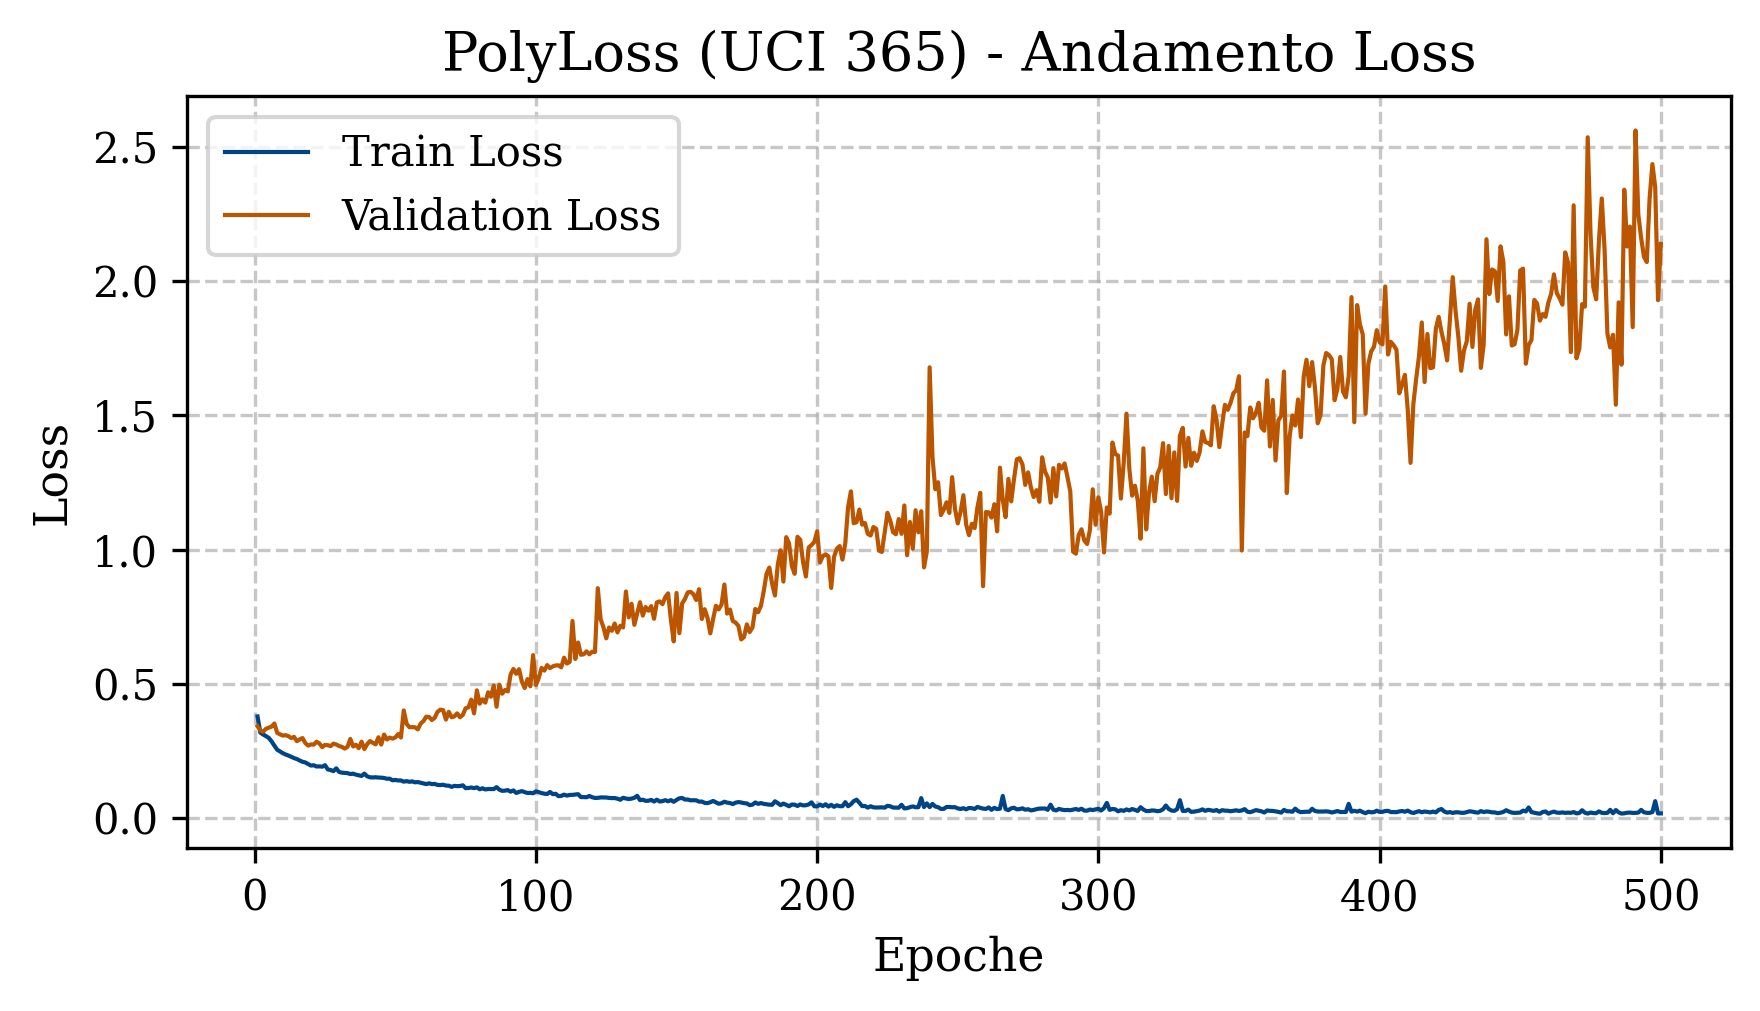

[*] Grafico salvato: results\{365}\plots\2026-05-11_16-47-05_PolyLoss_(UCI_365)_Accuracy.pdf


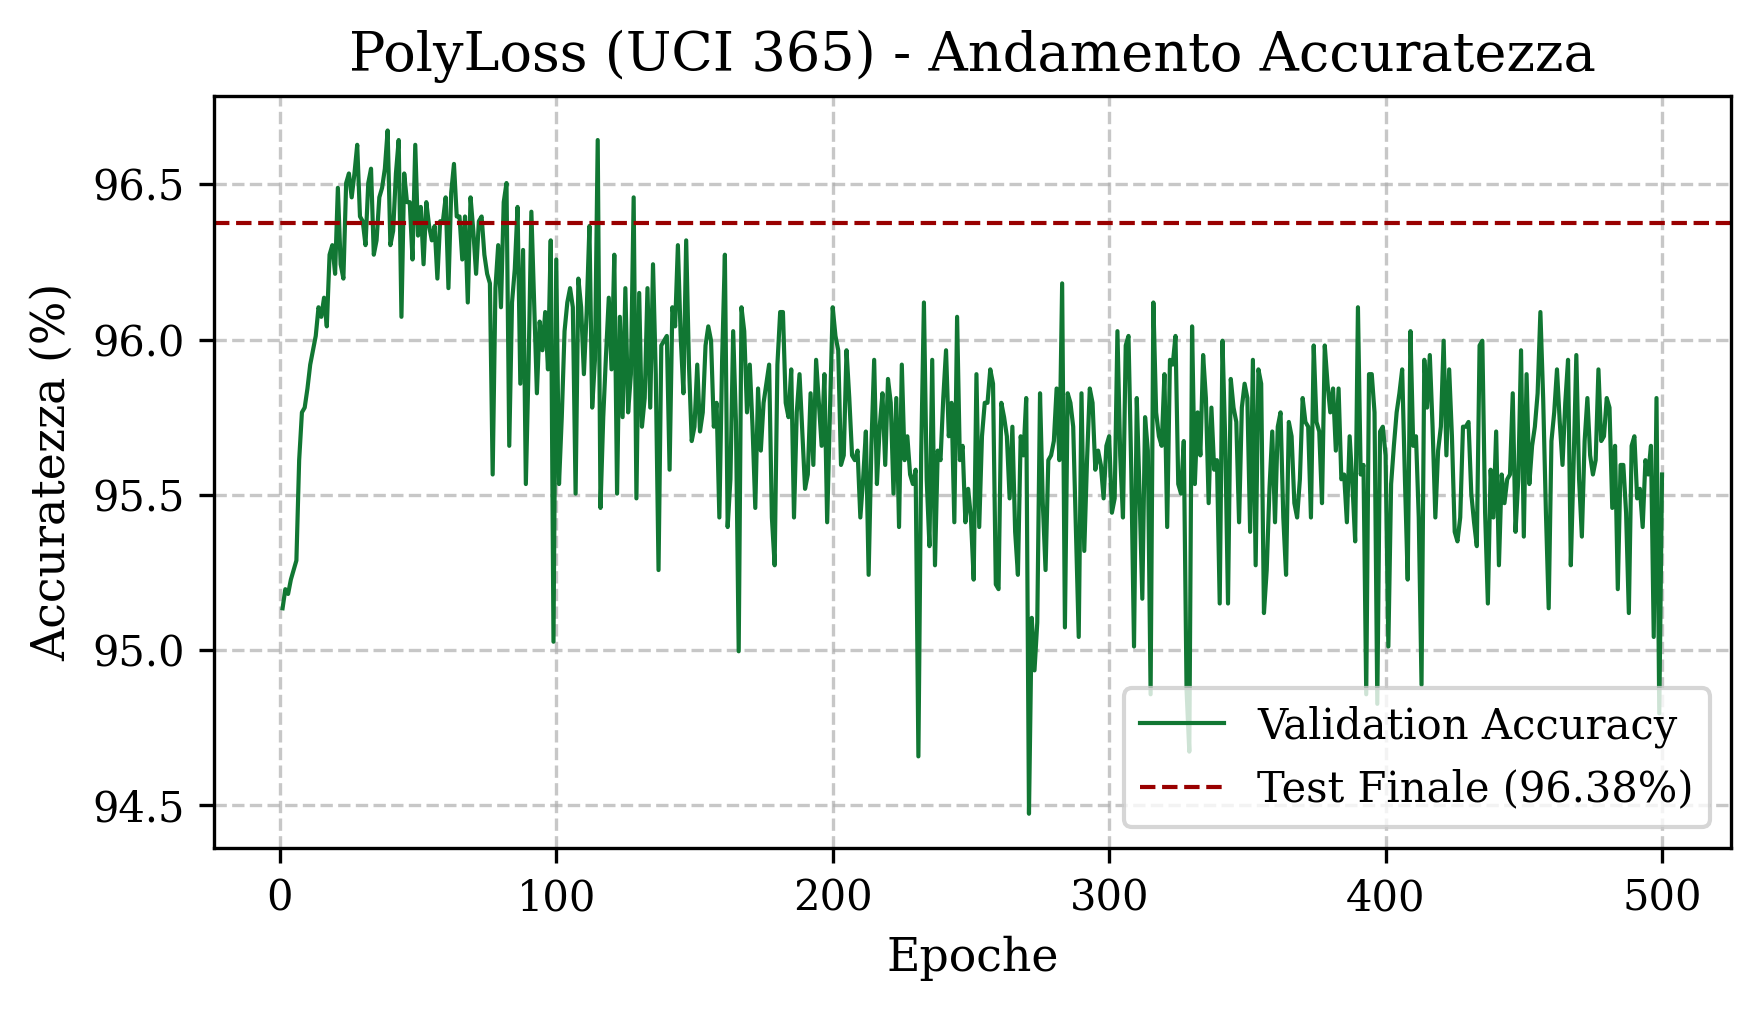

[*] Grafico salvato: results\{365}\plots\2026-05-11_16-47-05_PolyLoss_(UCI_365)_GDV.pdf


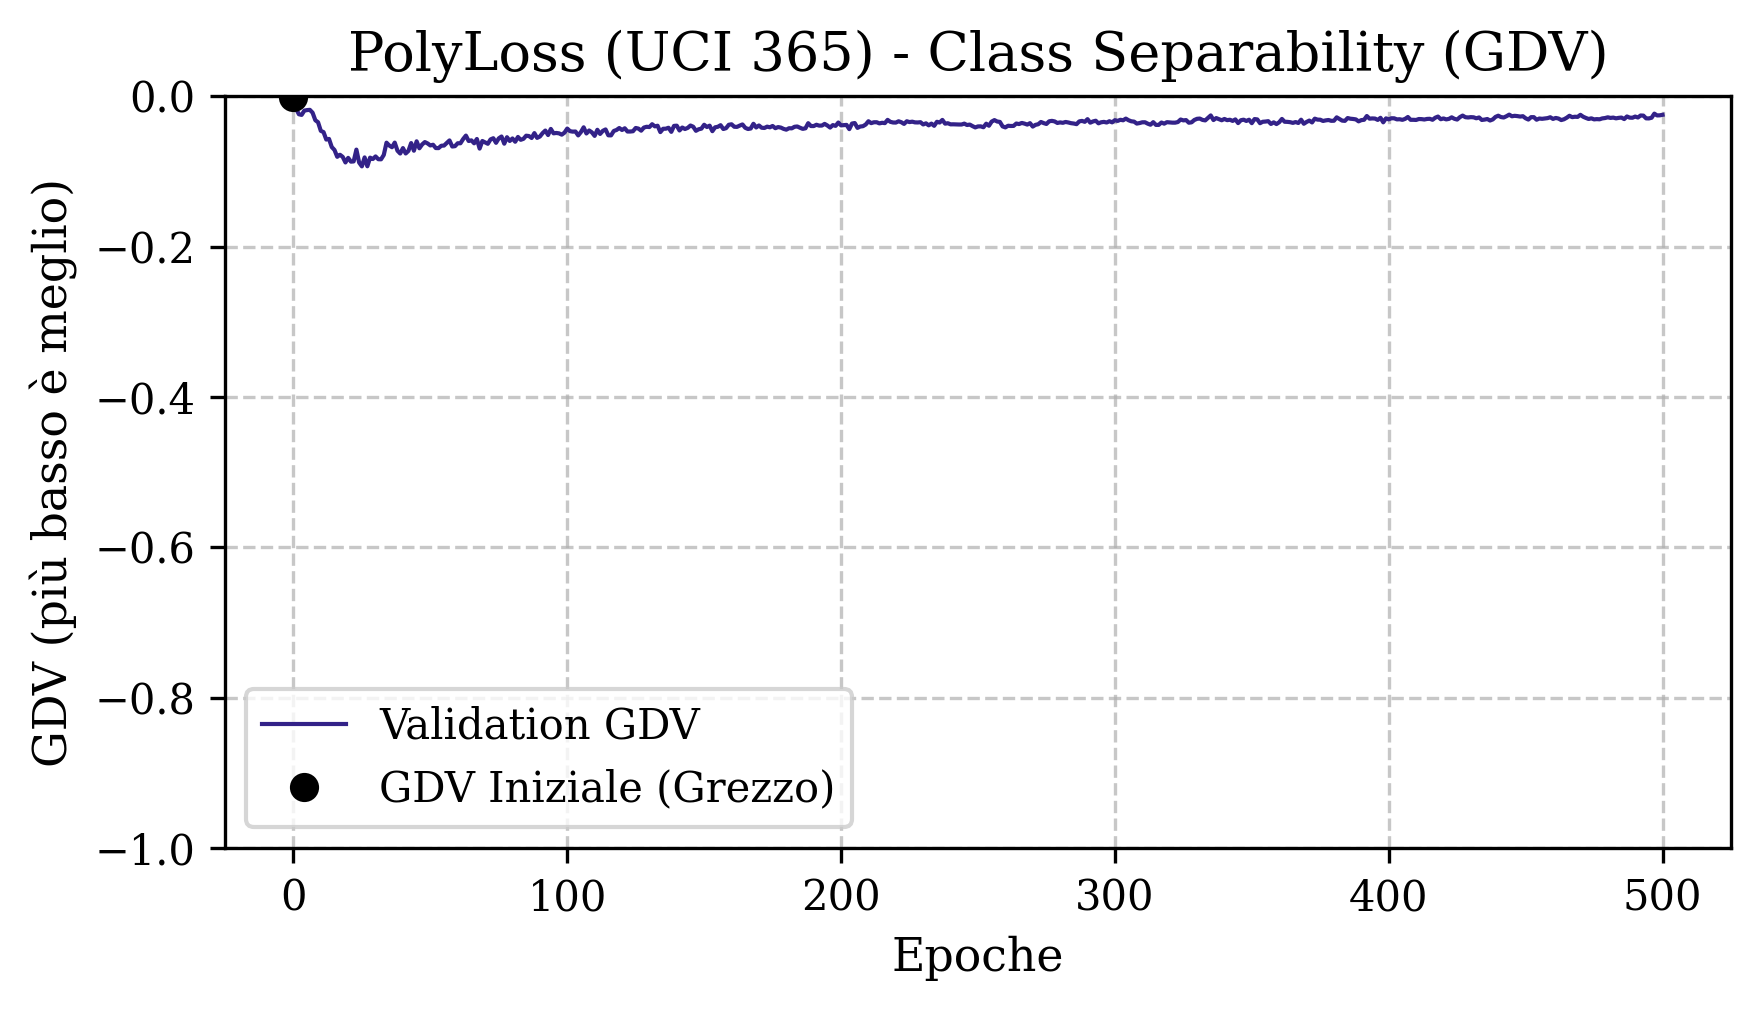

In [ ]:
# === ESPERIMENTO 2: POLYLOSS ===
print(f"\nAvvio Addestramento: PolyLoss su Dataset UCI ID {dataset_id} (Hold-Out)")

eps = config.get('loss_params', {}).get('polyloss', {}).get('epsilon', 2.0)
nome_poly_plot = f"PolyLoss (e={eps}) - UCI {dataset_id}"

torch.manual_seed(config['dataset'].get('random_state', 42))

# Inizializzazione modello
model_poly = MLP(
    input_size=in_dim, 
    num_classes=n_classes,
    hidden_layers=config['model']['hidden_layers'],
    dropout_rate=config['model']['dropout_rate']
).to(device)

criterion_poly = PolyLoss(epsilon=eps)
optimizer_poly = optim.Adam(model_poly.parameters(), lr=config['training']['learning_rate'])

gdv_layer = model_poly.get_layer_for_gdv(index=config['model']['gdv_layer_index'])

history_poly, best_epoch_poly = train_model(
    model=model_poly, criterion=criterion_poly, optimizer=optimizer_poly, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=config['training']['epochs'], layer_for_gdv=gdv_layer
)

test_acc_poly = evaluate_model(model_poly, test_loader, device)
history_poly['test_acc'] = test_acc_poly
print(f"Accuratezza Test Finale: {test_acc_poly:.2f}%")

# MLOps: Salvataggio log e Grafici
utils.salva_storico_json(     
    history=history_poly,     
    nome_esperimento=f"HoldOut_PolyLoss_UCI_{dataset_id}",
    dataset_id=dataset_id 
)

plot_training_history(
    history_poly, 
    model_name=nome_poly_plot, 
    gdv_iniziale=GDV_INIZIALE,
    dataset_id=dataset_id
)


Avvio Addestramento: Combined C-Loss su Dataset UCI ID 365 (Hold-Out)
Epoca 01/500 | Train Loss: 0.1360 | Val Loss: 0.1248 | Val Acc: 95.13% | Val GDV: -0.0172
Epoca 05/500 | Train Loss: 0.1073 | Val Loss: 0.1210 | Val Acc: 95.21% | Val GDV: -0.0181
Epoca 10/500 | Train Loss: 0.0871 | Val Loss: 0.1112 | Val Acc: 95.87% | Val GDV: -0.0292
Epoca 15/500 | Train Loss: 0.0788 | Val Loss: 0.1073 | Val Acc: 96.12% | Val GDV: -0.0529
Epoca 20/500 | Train Loss: 0.0720 | Val Loss: 0.1024 | Val Acc: 96.26% | Val GDV: -0.0582
Epoca 25/500 | Train Loss: 0.0666 | Val Loss: 0.1005 | Val Acc: 96.47% | Val GDV: -0.0573
Epoca 30/500 | Train Loss: 0.0627 | Val Loss: 0.1055 | Val Acc: 96.43% | Val GDV: -0.0524
Epoca 35/500 | Train Loss: 0.0603 | Val Loss: 0.1131 | Val Acc: 96.49% | Val GDV: -0.0434
Epoca 40/500 | Train Loss: 0.0569 | Val Loss: 0.1329 | Val Acc: 96.49% | Val GDV: -0.0477
Epoca 45/500 | Train Loss: 0.0546 | Val Loss: 0.1347 | Val Acc: 96.47% | Val GDV: -0.0396
Epoca 50/500 | Train Loss: 0.

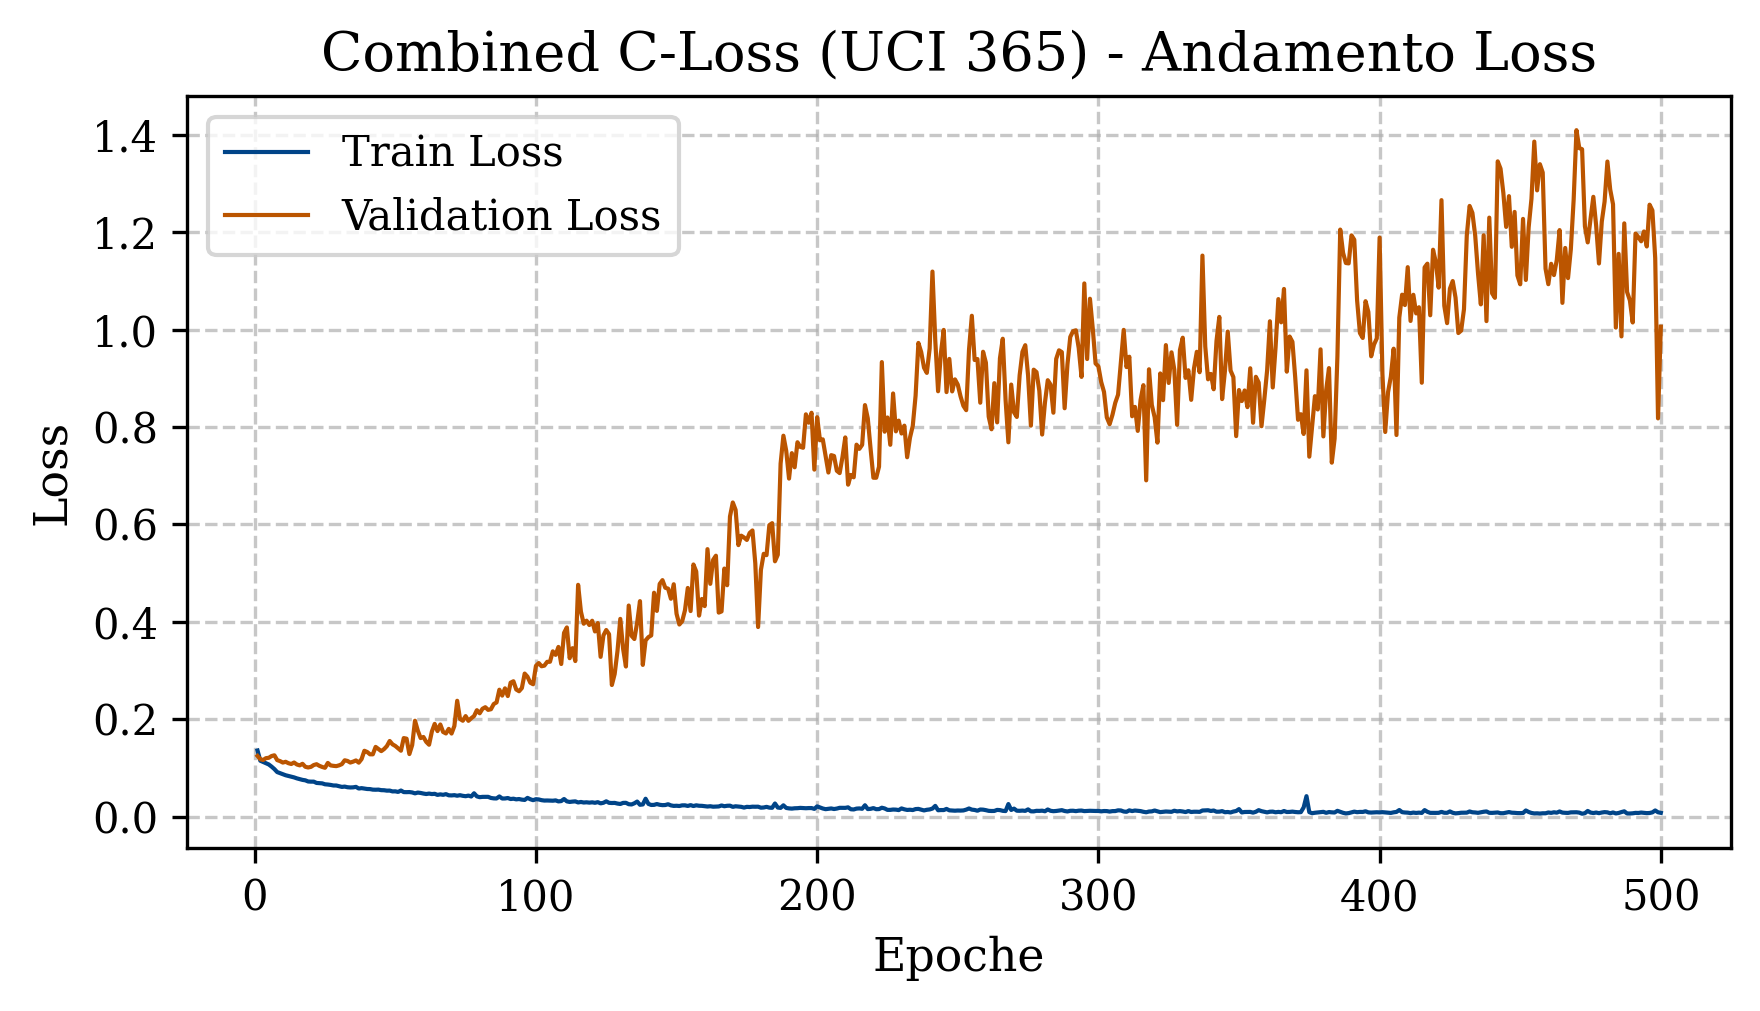

[*] Grafico salvato: results\{365}\plots\2026-05-11_16-57-08_Combined_C-Loss_(UCI_365)_Accuracy.pdf


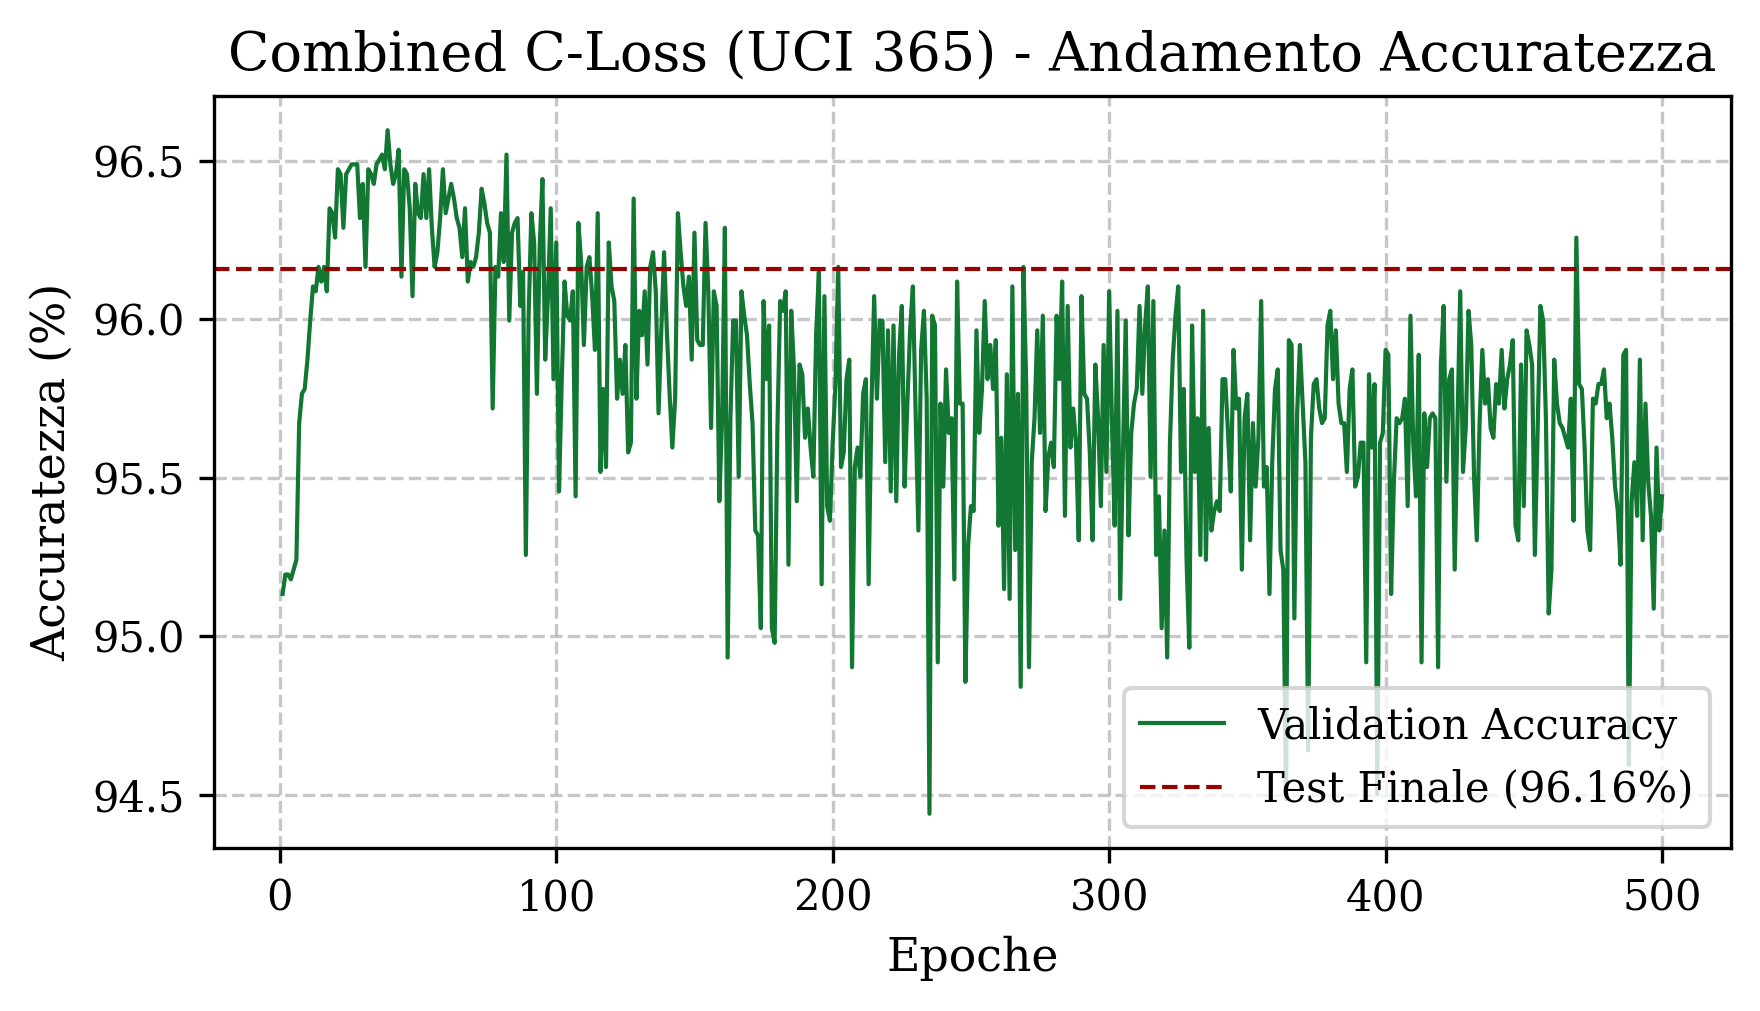

[*] Grafico salvato: results\{365}\plots\2026-05-11_16-57-08_Combined_C-Loss_(UCI_365)_GDV.pdf


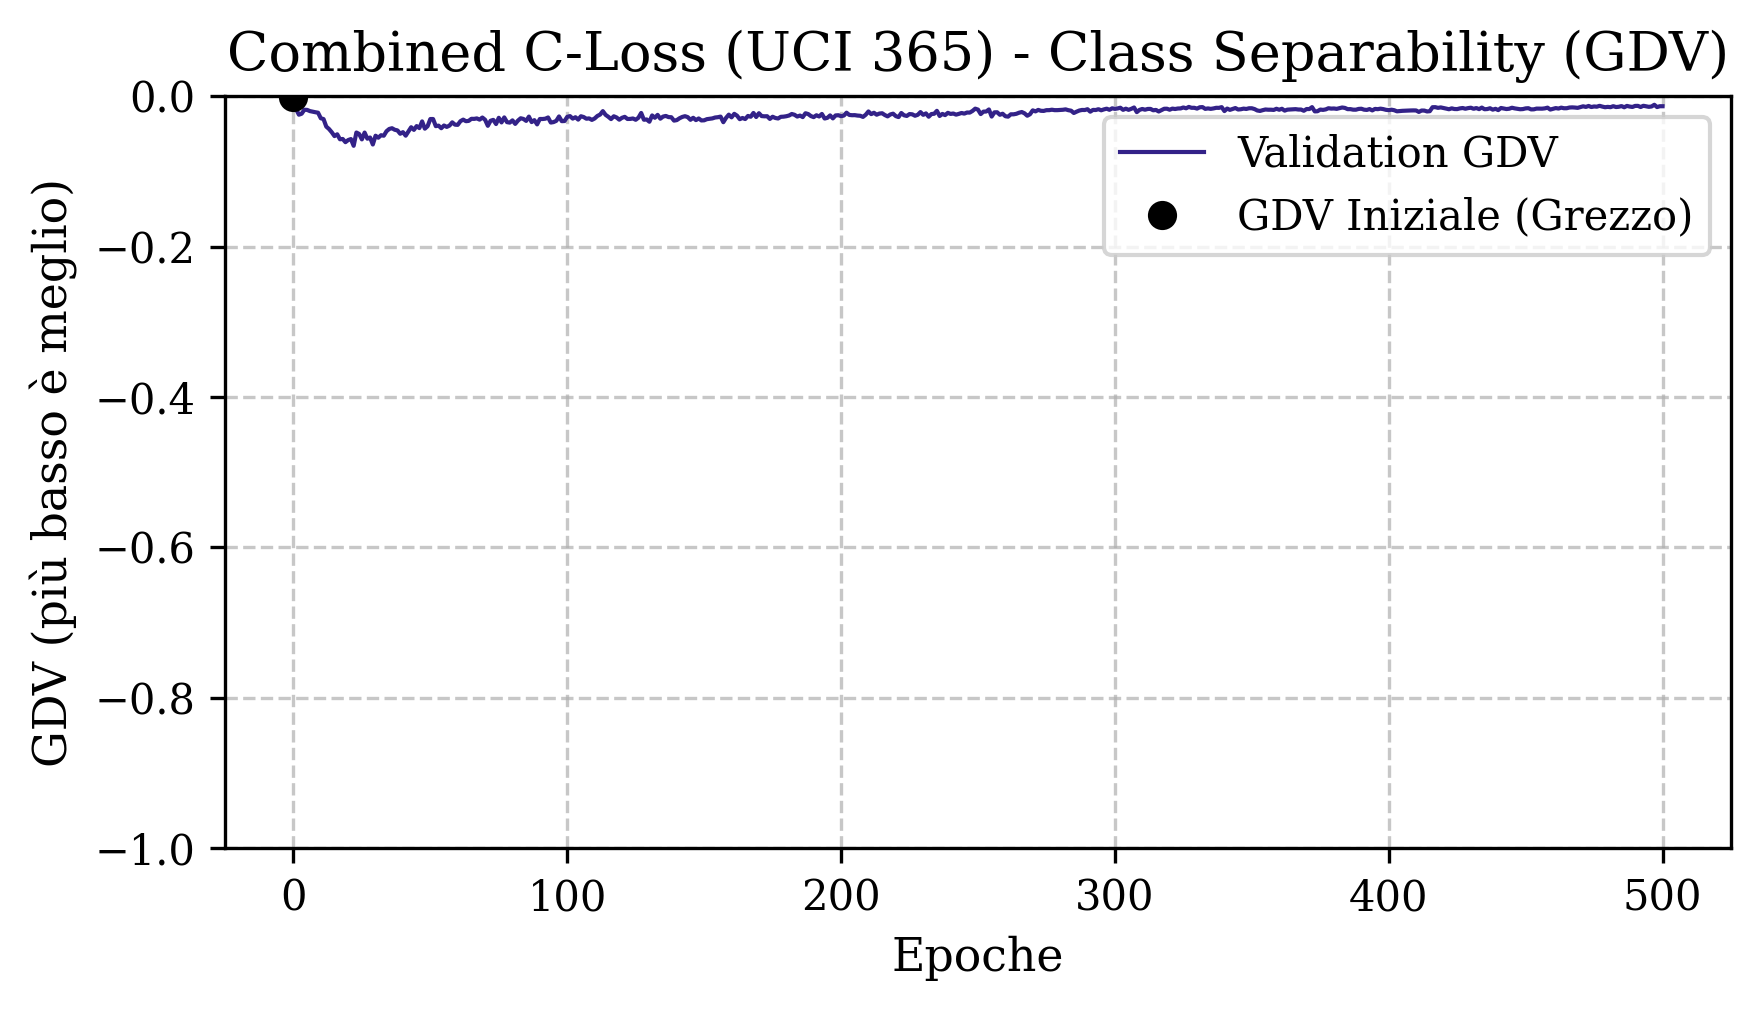

In [ ]:
# === ESPERIMENTO 3: COMBINED C-LOSS ===
print(f"\nAvvio Addestramento: Combined C-Loss su Dataset UCI ID {dataset_id} (Hold-Out)")

sig = config.get('loss_params', {}).get('closs', {}).get('sigma', 0.5)
gam = config.get('loss_params', {}).get('closs', {}).get('gamma', 0.5)
nome_closs_plot = f"Combined C-Loss (s={sig}, g={gam}) - UCI {dataset_id}"

torch.manual_seed(config['dataset'].get('random_state', 42))

# Inizializzazione modello
model_closs = MLP(
    input_size=in_dim, 
    num_classes=n_classes,
    hidden_layers=config['model']['hidden_layers'],
    dropout_rate=config['model']['dropout_rate']
).to(device)

# Uso dei parametri dinamici estratti dal config
criterion_closs = CombinedCLoss(sigma=sig, gamma=gam)
optimizer_closs = optim.Adam(model_closs.parameters(), lr=config['training']['learning_rate'])

gdv_layer = model_closs.get_layer_for_gdv(index=config['model']['gdv_layer_index'])

history_closs, best_epoch_closs = train_model(
    model=model_closs, criterion=criterion_closs, optimizer=optimizer_closs, 
    train_loader=train_loader, val_loader=val_loader, device=device,
    num_epochs=config['training']['epochs'], layer_for_gdv=gdv_layer
)

test_acc_closs = evaluate_model(model_closs, test_loader, device)
history_closs['test_acc'] = test_acc_closs
print(f"Accuratezza Test Finale: {test_acc_closs:.2f}%")

# MLOps: Salvataggio log e Grafici
utils.salva_storico_json(     
    history=history_closs,     
    nome_esperimento=f"HoldOut_CombinedCLoss_UCI_{dataset_id}",
    dataset_id=dataset_id 
)

plot_training_history(
    history_closs, 
    model_name=nome_closs_plot, 
    gdv_iniziale=GDV_INIZIALE,
    dataset_id=dataset_id
)

In [13]:
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from dataset import create_dataloader

from models import MLP

# --- FUNZIONE SCUDO PER LA RIPRODUCIBILITÀ ---
def imposta_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# === ESPERIMENTO K-FOLD DINAMICO ===
def run_kfold_experiment(loss_fn, model_name, X, y, in_dim, n_classes, config):
    # Estrazione parametri specifici per il K-Fold dal config
    k_splits = config.get('kfold', {}).get('k_splits', 10)
    epochs_kfold = config.get('kfold', {}).get('epochs', 20)
    
    batch_size = config['dataset']['batch_size']
    base_seed = config['dataset'].get('random_state', 42)
    
    print(f"\n=== AVVIO {k_splits}-FOLD CV: {model_name} ===")
    print(f"Configurazione: {epochs_kfold} epoche per fold")
    
    imposta_seed(base_seed)
    skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=base_seed)
    
    fold_accs = []
    fold_gdvs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- Fold {fold+1}/{k_splits} ---")
        
        seed_corrente = base_seed + fold
        imposta_seed(seed_corrente)
        
        # Estrazione Dati
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        # Il .fit() si fa SOLO sul Train set del fold corrente
        imputer = SimpleImputer(strategy='mean')
        X_tr_imputed = imputer.fit_transform(X_tr)
        X_va_imputed = imputer.transform(X_va)
        
        # --- SCALING ---
        # Lo scaler impara sui dati appena imputati
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_imputed)
        X_va_scaled = scaler.transform(X_va_imputed)
        
        # Uso di create_dataloader dal modulo dataset
        tr_loader = create_dataloader(X_tr_scaled, y_tr, batch_size=batch_size, shuffle=True)
        va_loader = create_dataloader(X_va_scaled, y_va, batch_size=batch_size, shuffle=False)
        
        # Inizializzazione o MLP
        model = MLP(
            input_size=in_dim, 
            num_classes=n_classes,
            hidden_layers=config['model']['hidden_layers'],
            dropout_rate=config['model']['dropout_rate']
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=config['training']['learning_rate'])
        gdv_layer = model.get_layer_for_gdv(index=config['model']['gdv_layer_index'])
        
        # Addestramento con le epoche specifiche del K-Fold
        history, best_ep = train_model(
            model=model, criterion=loss_fn, optimizer=optimizer,
            train_loader=tr_loader, val_loader=va_loader, device=device,
            num_epochs=epochs_kfold,
            layer_for_gdv=gdv_layer
        )
        
        # Valutazione
        acc = evaluate_model(model, va_loader, device)
        fold_accs.append(acc)
        
        best_gdv = history['val_gdv'][best_ep - 1] if history['val_gdv'] else 0.0
        fold_gdvs.append(best_gdv)
        
    return fold_accs, fold_gdvs

k_val = config.get('kfold', {}).get('k_splits', 10)
print(f"\n=== ESECUZIONE {k_val}-FOLD CV SU UCI ID {dataset_id} ===")

# 1. Estrazione dinamica degli iperparametri delle Loss dal config
eps = config.get('loss_params', {}).get('polyloss', {}).get('epsilon', 2.0)
sig = config.get('loss_params', {}).get('closs', {}).get('sigma', 0.5)
gam = config.get('loss_params', {}).get('closs', {}).get('gamma', 0.5)

# 2. Creazione nomi dinamici (così nel JSON e nei grafici vedi subito i parametri usati)
nome_poly = f"PolyLoss (e={eps})"
nome_closs = f"C-Loss (s={sig}, g={gam})"

# 3. Esecuzione passando i parametri estratti
acc_ce, gdv_ce = run_kfold_experiment(nn.CrossEntropyLoss(), "Cross-Entropy", X_raw, y_encoded, in_dim, n_classes, config)
acc_poly, gdv_poly = run_kfold_experiment(PolyLoss(epsilon=eps), nome_poly, X_raw, y_encoded, in_dim, n_classes, config)
acc_closs, gdv_closs = run_kfold_experiment(CombinedCLoss(sigma=sig, gamma=gam), nome_closs, X_raw, y_encoded, in_dim, n_classes, config)

# Salvataggio MLOps
kfold_results = {
    "dataset_id": dataset_id,
    "folds": k_val,
    "Cross-Entropy": {"acc": acc_ce, "gdv": gdv_ce},
    nome_poly: {"acc": acc_poly, "gdv": gdv_poly},
    nome_closs: {"acc": acc_closs, "gdv": gdv_closs}
}

utils.salva_storico_json(     
    history=kfold_results,     
    nome_esperimento="KFold_Results", 
    dataset_id=dataset_id
)

print("\n" + "="*50)
print("--- RIEPILOGO FINALE K-FOLD (Accuratezza Media) ---")
print(f"1. Cross-Entropy: {np.mean(acc_ce):.2f}% (± {np.std(acc_ce):.2f}%)")
print(f"2. {nome_poly}: {np.mean(acc_poly):.2f}% (± {np.std(acc_poly):.2f}%)")
print(f"3. {nome_closs}: {np.mean(acc_closs):.2f}% (± {np.std(acc_closs):.2f}%)")


=== ESECUZIONE 10-FOLD CV SU UCI ID 365 ===

=== AVVIO 10-FOLD CV: Cross-Entropy ===
Configurazione: 200 epoche per fold

--- Fold 1/10 ---
Epoca 01/200 | Train Loss: 0.1983 | Val Loss: 0.1746 | Val Acc: 95.21% | Val GDV: -0.0196
Epoca 05/200 | Train Loss: 0.1620 | Val Loss: 0.1556 | Val Acc: 95.23% | Val GDV: -0.0394
Epoca 10/200 | Train Loss: 0.1328 | Val Loss: 0.1285 | Val Acc: 95.92% | Val GDV: -0.0508
Epoca 15/200 | Train Loss: 0.1201 | Val Loss: 0.1214 | Val Acc: 96.15% | Val GDV: -0.0628
Epoca 20/200 | Train Loss: 0.1085 | Val Loss: 0.1105 | Val Acc: 96.59% | Val GDV: -0.0736
Epoca 25/200 | Train Loss: 0.1001 | Val Loss: 0.1162 | Val Acc: 96.54% | Val GDV: -0.0794
Epoca 30/200 | Train Loss: 0.0935 | Val Loss: 0.1061 | Val Acc: 96.84% | Val GDV: -0.0745
Epoca 35/200 | Train Loss: 0.0892 | Val Loss: 0.1035 | Val Acc: 96.98% | Val GDV: -0.0674
Epoca 40/200 | Train Loss: 0.0920 | Val Loss: 0.1132 | Val Acc: 96.59% | Val GDV: -0.0713
Epoca 45/200 | Train Loss: 0.0823 | Val Loss: 0.1

[*] Grafico K-Fold salvato per la tesi in: results\365\plots\2026-05-11_19-41-11_KFold_Acc.pdf


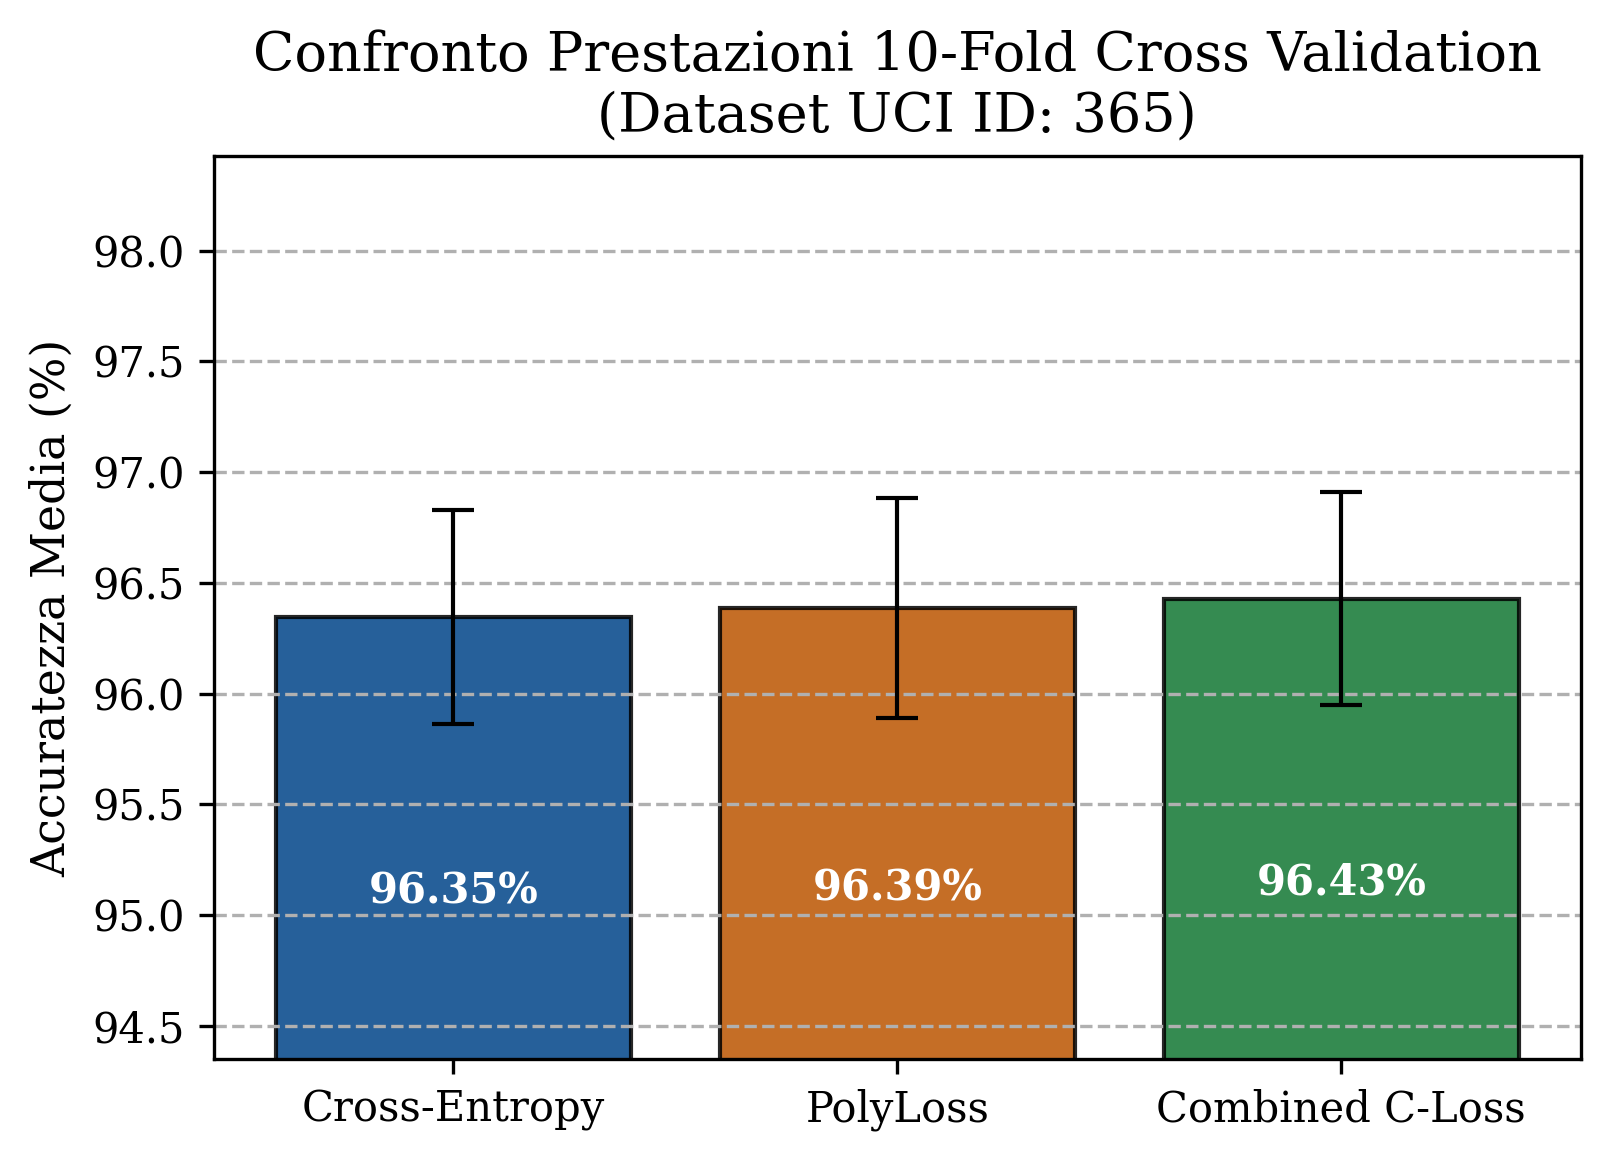

In [14]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(5.5, 4.0))

modelli = ['Cross-Entropy', 'PolyLoss', 'Combined C-Loss']
medie_acc = [np.mean(acc_ce), np.mean(acc_poly), np.mean(acc_closs)]
std_acc = [np.std(acc_ce), np.std(acc_poly), np.std(acc_closs)]

colori = ['#004488', '#BB5500', '#117733']

barre = ax1.bar(modelli, medie_acc, yerr=std_acc, capsize=5, 
                color=colori, alpha=0.85, edgecolor='black', linewidth=1.0,
                error_kw={'elinewidth': 1.0, 'capthick': 1.0})

min_acc = min(medie_acc) - max(std_acc) - 1.5
max_acc = max(medie_acc) + max(std_acc) + 1.5
ax1.set_ylim(min_acc, max_acc)

ax1.set_ylabel('Accuratezza Media (%)')
ax1.set_title(f'Confronto Prestazioni 10-Fold Cross Validation\n(Dataset UCI ID: {dataset_id})')

for i, (barra, media) in enumerate(zip(barre, medie_acc)):
    altezza = barra.get_height()
    base_error_bar = altezza - std_acc[i]
    y_text = min_acc + (base_error_bar - min_acc) / 2
    
    ax1.text(barra.get_x() + barra.get_width()/2., y_text, 
             f'{media:.2f}%', ha='center', va='center', 
             color='white', fontweight='bold', fontsize=10)

plt.grid(axis='y', linestyle='--')
plt.tight_layout()

# ==========================================
# SALVATAGGIO MLOPS
# ==========================================
base_dir = "results"
save_dir = os.path.join(base_dir, str(dataset_id), "plots")
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename_pdf = os.path.join(save_dir, f"{timestamp}_KFold_Acc.pdf")

plt.savefig(filename_pdf, format='pdf', bbox_inches='tight')
print(f"[*] Grafico K-Fold salvato per la tesi in: {filename_pdf}")

plt.show()